# De blancos moleculares a candidatos a ligando

El recorrido reproduce cuatro decisiones tempranas del descubrimiento de antibacterianos:

1. priorizar blancos con una salida precomputada de **FastTarget**;
2. transferir evidencia de ligandos con **LigQ2**;
3. comparar propiedades fisicoquímicas y predicciones **ADMET**;
4. modelar un complejo proteína–ligando con **Boltz-2** y plantear un docking dirigido.

No hay respuestas para entregar. Las preguntas son disparadores para discutir durante la clase. Ningún score demuestra por sí solo esencialidad, unión, eficacia ni seguridad.

## Preparación

Las dos celdas siguientes **no realizan todavía ningún análisis biológico**. Su única función es preparar el entorno:

1. descargar los archivos que utilizará el notebook;
2. importar las bibliotecas de Python;
3. leer el TSV de FastTarget en una tabla llamada `ft`.

Si finalizan con el mensaje `Datos listos` y muestran las primeras cinco proteínas, se puede comenzar la Parte I.

In [26]:
DATA_BASE_URL = "https://raw.githubusercontent.com/mcpalumbo/tp-ligandos/main/datos_tp"

from pathlib import Path
from urllib.request import urlretrieve
import zipfile
import shutil

# En Colab, /content es un espacio temporal que se borra al cerrar la sesión.
DATA_DIR = Path("/content/datos_tp")
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Estos son todos los archivos que utilizará el práctico.
ARCHIVOS=["manifest.json","fasttarget_resultados.tsv","P78021.fasta","AF_P78021.pdb",
 "AF_P78021_pocket1_atm.pdb","AF_P78021_pocket1_vert.pqr","AF_P78021_fpocket_info.txt","ligq_ligA_results.zip"]

if DATA_BASE_URL.startswith("http"):
 # Modalidad normal: descargar cada archivo desde GitHub.
 for nombre in ARCHIVOS:
  urlretrieve(f"{DATA_BASE_URL.rstrip('/')}/{nombre}", DATA_DIR/nombre)
else:
 # Modalidad de respaldo: cargar manualmente datos_tp.zip.
 from google.colab import files
 print("Por favor, sube el archivo .zip con los datos (ej. datos_tp.zip o ligq_ligA_results.zip).")
 subidos = files.upload()
 nombre_zip = next(n for n in subidos if n.lower().endswith(".zip"))
 with zipfile.ZipFile(nombre_zip) as archivo_zip:
  archivo_zip.extractall(DATA_DIR) # Modificado para extraer directamente a DATA_DIR
 print(f"Extraído {nombre_zip} a {DATA_DIR}")
 # Eliminar el archivo zip subido de la raíz /content para evitar conflictos
 Path(nombre_zip).unlink(missing_ok=True)

# Detener el notebook inmediatamente si falta algún dato.
faltantes = [n for n in ARCHIVOS if not (DATA_DIR/n).exists()]
assert not faltantes, f"Faltan archivos: {faltantes}"
print("Datos listos")

Por favor, sube el archivo .zip con los datos (ej. datos_tp.zip o ligq_ligA_results.zip).


Saving datos_tp.zip to datos_tp.zip
Extraído datos_tp.zip a /content/datos_tp
Datos listos


In [32]:
# Este comando se ha eliminado porque los archivos ya se extraen directamente a la carpeta correcta en la celda anterior.

In [27]:
# Bibliotecas para trabajar con tablas y gráficos.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid")

# sep="\t" indica que el archivo TSV usa tabulaciones como separador.
ft = pd.read_csv(DATA_DIR / "fasttarget_resultados.tsv", sep="\t")
print(f"{len(ft)} proteínas; {ft.shape[1]} columnas")
display(ft.head())

679 proteínas; 8 columnas


,gene,gene_name,uniprot,druggability_score,hit_in_deg,human_offtarget,gut_microbiome_offtarget,betweenness_centrality
0,MPN_RS00005,dnaN,Q50313,0.340,True,no_hit,no_hit,0.0
1,MPN_RS00010,MPN_RS00010,Q50312,0.761,False,51.351,no_hit,0.0
2,MPN_RS00015,gyrB,P22447,0.451,True,27.211,1.0,0.0
3,MPN_RS00020,gyrA,P22446,0.737,True,28.453,1.0,0.0
4,MPN_RS00025,serS,P75107,0.452,True,40.157,0.643,0.0


# Parte I — Búsqueda de blancos moleculares

Un **blanco molecular** es una molécula del patógeno cuya alteración podría impedir su crecimiento o supervivencia. En este caso buscamos proteínas bacterianas que puedan ser inhibidas por moléculas pequeñas y que, al mismo tiempo, tengan bajo riesgo de interferir con proteínas humanas.

**FastTarget** no decide automáticamente cuál es el mejor blanco. Calcula evidencias independientes para cada proteína y las reúne en una tabla. El investigador debe decidir qué evidencias considera necesarias y cómo las combina.

Aquí usamos cuatro ejes:

- **Druggability estructural:** FPocket representa la superficie de la proteína mediante esferas, localiza cavidades y describe su tamaño, forma, polaridad e hidrofobicidad. `druggability_score` corresponde al bolsillo con mayor estimación de drogabilidad. Un valor alto sugiere que una molécula pequeña podría acomodarse allí, pero no demuestra que exista un inhibidor.
- **Esencialidad:** FastTarget compara las secuencias contra la **Database of Essential Genes (DEG)**. `hit_in_deg=True` significa que encontró una proteína semejante a otra considerada esencial en algún organismo. No demuestra que el gen sea esencial en *M. pneumoniae*.
- **Off-targets:** un off-target es una proteína no deseada que también podría reconocer el compuesto. `human_offtarget=no_hit` significa que no se detectó un homólogo humano bajo los parámetros utilizados. `gut_microbiome_offtarget` estima en qué fracción de especies de la microbiota se encontraron proteínas similares.
- **Centralidad:** se construye una red donde los nodos representan reacciones o proteínas conectadas por metabolitos. `betweenness_centrality` aumenta cuando un nodo aparece con frecuencia en los caminos más cortos que conectan la red. Una proteína central podría afectar varios flujos, aunque centralidad y esencialidad no son sinónimos.

La tabla contiene sólo estas evidencias y tres identificadores: `gene` es el locus tag, `gene_name` es el nombre corto cuando está anotado y `uniprot` permite consultar información externa.

### Antes de filtrar: conocer la tabla

`describe()` resume cada columna: cantidad de valores, media, dispersión y extremos para variables numéricas, o frecuencia de categorías para texto. Los histogramas permiten comprobar si los scores se distribuyen de manera uniforme o si la mayoría de las proteínas queda concentrada cerca de cero.

Esto es importante porque un mismo umbral puede ser muy permisivo para una variable y muy estricto para otra.

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gene,679,679,MPN_RS03870,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gene_name,679,678,rpmG,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
uniprot,632,630,P75372,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
druggability_score,603.0,NaN,NaN,NaN,0.638982,0.228227,0.021,0.532,0.689,0.812,0.964
hit_in_deg,679,2,True,447,NaN,NaN,NaN,NaN,NaN,NaN,NaN
human_offtarget,679,180,no_hit,489,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gut_microbiome_offtarget,679,164,no_hit,382,NaN,NaN,NaN,NaN,NaN,NaN,NaN
betweenness_centrality,679.0,NaN,NaN,NaN,0.012451,0.06631,0.0,0.0,0.0,0.0,0.764028


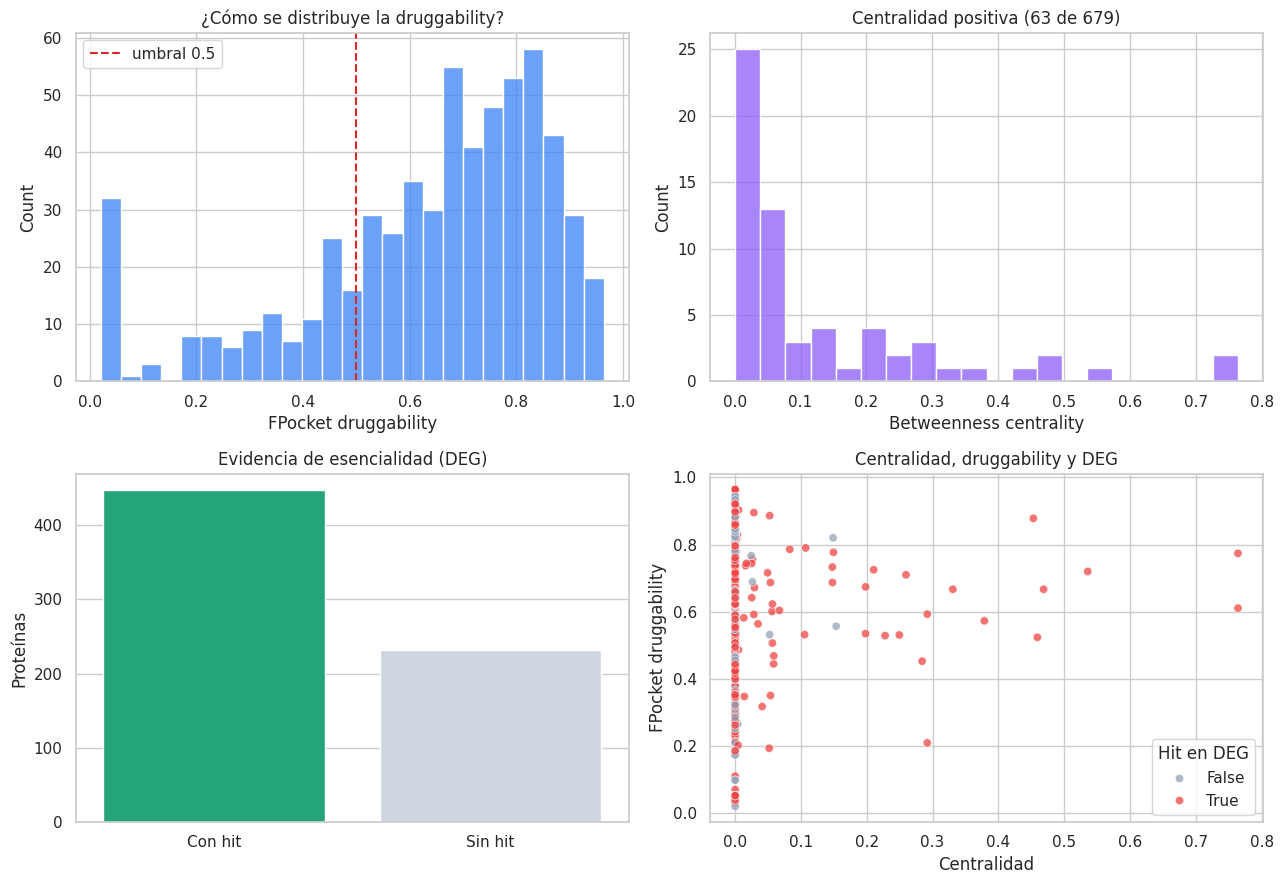

In [28]:
# Resumen estadístico: una fila por variable.
display(ft.describe(include="all").T)

# Convertimos microbiota a números sólo para poder graficarla.
# "no_hit" se representa como 0: no se detectaron coincidencias.
micro_grafico = pd.to_numeric(ft["gut_microbiome_offtarget"], errors="coerce").fillna(0)

# Dashboard de cuatro paneles para describir el resultado completo.
fig, ax = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(ft["druggability_score"], bins=25, color="#3B82F6", ax=ax[0,0])
ax[0,0].axvline(0.5, color="#DC2626", ls="--", label="umbral 0.5")
ax[0,0].set(title="¿Cómo se distribuye la druggability?", xlabel="FPocket druggability")
ax[0,0].legend()

# Hay muchos ceros de centralidad; se muestran en una barra separada del resto.
centrales = ft[ft["betweenness_centrality"] > 0]["betweenness_centrality"]
sns.histplot(centrales, bins=20, color="#8B5CF6", ax=ax[0,1])
ax[0,1].set(title=f"Centralidad positiva ({len(centrales)} de {len(ft)})",
            xlabel="Betweenness centrality")

deg_counts = ft["hit_in_deg"].fillna(False).map({True:"Con hit",False:"Sin hit"}).value_counts()
sns.barplot(x=deg_counts.index, y=deg_counts.values, hue=deg_counts.index,
            palette=["#10B981","#CBD5E1"], legend=False, ax=ax[1,0])
ax[1,0].set(title="Evidencia de esencialidad (DEG)", xlabel="", ylabel="Proteínas")

# Relación entre las dos variables que luego formarán el score.
sns.scatterplot(data=ft, x="betweenness_centrality", y="druggability_score",
                hue=ft["hit_in_deg"].fillna(False), palette={True:"#EF4444",False:"#94A3B8"},
                alpha=.75, ax=ax[1,1])
ax[1,1].set(title="Centralidad, druggability y DEG", xlabel="Centralidad",
            ylabel="FPocket druggability")
ax[1,1].legend(title="Hit en DEG")

plt.tight_layout(); plt.show()

### Filtros modificables

La celda siguiente es interactiva. **Ejecuten la celda una vez y después muevan las barras** de druggability y microbiota o activen/desactiven las casillas. La tabla y los gráficos se actualizan automáticamente.

No busquen inmediatamente “el mejor” umbral: observen cuánto cambia el número de candidatos y qué proteínas entran o salen. El punto de partida sugerido exige DEG, ausencia de hit humano, menos del 30 % de hits en microbiota y druggability mayor que 0.5.

In [99]:
#@title **Explorar filtros de proteínas**
# La columna mezcla números y "no_hit"; para filtrar, "no_hit" se toma como 0.
micro = pd.to_numeric(ft["gut_microbiome_offtarget"], errors="coerce").fillna(0)

druggability = 0.8 #@param {type:"slider", min:0, max:1, step:0.05, description:"Druggability >"}

max_microbiota = 0.30 #@param {type:"slider", min:0, max:1, step:0.05, description:"Microbiota <"}

exigir_deg = True #@param {type:"boolean", description:"Exigir hit en DEG"}

excluir_humano = True #@param {type:"boolean", description:"Excluir hit humano"}

centralidad_positiva = True #@param {type:"boolean", description:"Centralidad > 0"}

global candidatos

mask = (ft["druggability_score"] > druggability) & (micro < max_microbiota)
if exigir_deg:
    mask &= ft["hit_in_deg"].eq(True)
if excluir_humano:
    mask &= ft["human_offtarget"].eq("no_hit")
if centralidad_positiva:
    mask &= ft["betweenness_centrality"] > 0

candidatos = ft.loc[mask].copy()
candidatos["microbiota_num"] = micro[mask]

print(f"PROTEÍNAS QUE PASAN: {len(candidatos)} / {len(ft)}")
if candidatos.empty:
    print("Ninguna proteína supera esta combinación de filtros.")

PROTEÍNAS QUE PASAN: 2 / 679


### Gráficos del conjunto seleccionado

Una vez explorados los umbrales con los selectores, ejecuten esta celda aparte. Los gráficos se construyen con la última combinación elegida y ayudan a interpretar qué cambió, sin volver a crear los controles.

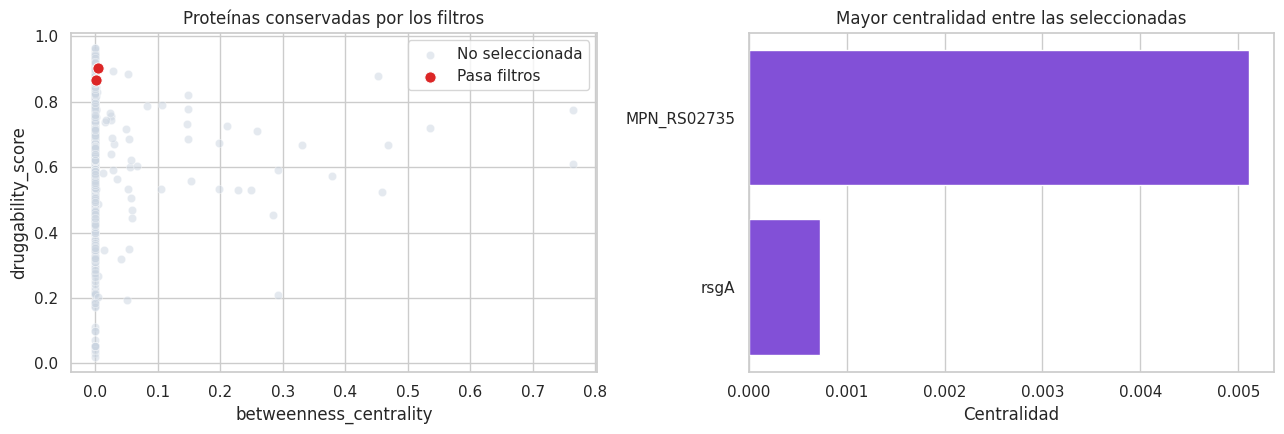

,gene_name,gene,uniprot,druggability_score,betweenness_centrality,microbiota_num
461,MPN_RS02735,MPN_RS02735,P75305,0.903,0.005109,0.001
247,rsgA,MPN_RS01380,P75523,0.867,0.000728,0.000


In [100]:
# Estos gráficos usan la última selección guardada en la variable candidatos.
if candidatos.empty:
 print("No hay proteínas seleccionadas; relajen algún filtro y vuelvan a ejecutar los selectores.")
else:
 fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
 sns.scatterplot(data=ft, x="betweenness_centrality", y="druggability_score",
                 color="#CBD5E1", alpha=.5, ax=ax[0], label="No seleccionada")
 sns.scatterplot(data=candidatos, x="betweenness_centrality", y="druggability_score",
                 color="#DC2626", s=65, ax=ax[0], label="Pasa filtros")
 ax[0].set_title("Proteínas conservadas por los filtros")

 top = candidatos.nlargest(12, "betweenness_centrality").copy()
 top["etiqueta"] = top["gene_name"].fillna(top["gene"])
 sns.barplot(data=top, y="etiqueta", x="betweenness_centrality",
             color="#7C3AED", ax=ax[1])
 ax[1].set_title("Mayor centralidad entre las seleccionadas")
 ax[1].set(xlabel="Centralidad", ylabel="")
 plt.tight_layout(); plt.show()

 display(candidatos[["gene_name","gene","uniprot","druggability_score",
                     "betweenness_centrality","microbiota_num"]]
         .sort_values("betweenness_centrality",ascending=False).head(12))

### Scoring modificable

Druggability y centralidad no recorren el mismo intervalo en estos datos. Si se sumaran directamente, la variable con mayor rango tendría más influencia aunque los pesos fueran iguales.

Aplicaremos una normalización min–max **dentro del conjunto filtrado**:

$$x_{norm}=rac{x-x_{min}}{x_{max}-x_{min}}$$

El valor mínimo pasa a 0, el máximo a 1 y los demás conservan su posición relativa. Luego calculamos una media ponderada. El resultado es un **score de priorización interno**: permite ordenar este conjunto, pero no representa una probabilidad de éxito farmacológico. Si cambian los filtros, cambian los mínimos y máximos y el score debe recalcularse.

In [89]:
#@title Elegir pesos
PESO_CENTRALIDAD=0.50 #@param {type:"slider",min:0,max:1,step:0.05}
PESO_DROGABILIDAD=0.50 #@param {type:"slider",min:0,max:1,step:0.05}
def minmax(s):
 # Convertir a números y aplicar la ecuación min–max.
 s = pd.to_numeric(s, errors="coerce")
 return (s-s.min())/(s.max()-s.min()) if s.max()>s.min() else s*0

# Evitamos calcular un ranking vacío o dividir por cero si ambos pesos son 0.
assert len(candidatos) and PESO_CENTRALIDAD+PESO_DROGABILIDAD>0

ranking = candidatos.copy()
ranking["centralidad_norm"] = minmax(ranking.betweenness_centrality)
ranking["druggability_norm"]=minmax(ranking.druggability_score)

# Media ponderada: cada score normalizado se multiplica por su peso.
ranking["score"]=(PESO_CENTRALIDAD*ranking.centralidad_norm+PESO_DROGABILIDAD*ranking.druggability_norm)/(PESO_CENTRALIDAD+PESO_DROGABILIDAD)
ranking=ranking.sort_values("score",ascending=False)
cols=["gene_name","gene","uniprot","score","betweenness_centrality","druggability_score","hit_in_deg","human_offtarget","microbiota_num"]
display(ranking[cols].head(20).style.background_gradient(subset=["score"],cmap="YlGn"))

,gene_name,gene,uniprot,score,betweenness_centrality,druggability_score,hit_in_deg,human_offtarget,microbiota_num
351,ligA,MPN_RS01995,P78021,0.602364,0.210400,0.725000,True,no_hit,0.087000
619,pyrH,MPN_RS03585,P75165,0.599352,0.291847,0.593000,True,no_hit,0.009000
329,MPN_RS01880,MPN_RS01880,P75442,0.553884,0.149325,0.777000,True,no_hit,0.002000
344,plsY,MPN_RS01960,P75428,0.526321,0.198161,0.674000,True,no_hit,0.004000
552,MPN_RS03240,MPN_RS03240,P75213,0.500000,0.000000,0.964000,True,no_hit,0.000000
590,MPN_RS03440,MPN_RS03440,Q50326,0.500000,0.000000,0.964000,True,no_hit,0.000000
336,MPN_RS01915,MPN_RS01915,P75435,0.495680,0.000000,0.960000,True,no_hit,0.207000
268,MPN_RS01485,MPN_RS01485,Q9EXD1,0.473002,0.000000,0.939000,True,no_hit,0.000000
266,MPN_RS01475,MPN_RS01475,P75507,0.470842,0.000000,0.937000,True,no_hit,0.000000
302,MPN_RS01740,MPN_RS01740,P0CJ81,0.467603,0.000000,0.934000,True,no_hit,0.009000


**Para discutir:** ¿se mantienen las primeras candidatas al cambiar filtros y pesos? ¿Cuáles suben sólo por FPocket? ¿Excluir centralidad cero corrige un problema o puede ocultar proteínas mal representadas en la red?

## Caso guiado: LigA

LigA (`MPN_RS01995`, [UniProt P78021](https://www.uniprot.org/uniprotkb/P78021/entry)) es una DNA ligasa bacteriana dependiente de NAD⁺, necesaria para replicación y reparación. Las ligasas humanas principales utilizan ATP y son diferentes.

LigA se estudió como blanco antibacteriano y existen inhibidores con evidencia bioquímica, genética, estructural, celular y en modelos animales. Una serie inhibió también LigA de *M. pneumoniae* en rango nanomolar y tuvo actividad contra la bacteria. No existe todavía un antibiótico clínico dirigido a LigA.

- [Validación e inhibidores de amplio espectro](https://pmc.ncbi.nlm.nih.gov/articles/PMC3067096/)
- [Inhibidor que evita una mutación de resistencia](https://doi.org/10.1016/j.bmcl.2013.11.007)

P78021 no tiene estructura experimental en PDB: UniProt enlaza AlphaFold/SMR. Sus features inferidas por homología son: Lys112 activa; NAD⁺ en 31–35, 80–81, 110, 133, 167, 279 y 303; Zn²⁺ en 397, 400, 415 y 420.

### Estructura experimental, modelo y pocket

El **Protein Data Bank (PDB)** almacena estructuras determinadas experimentalmente, por ejemplo mediante cristalografía de rayos X. **AlphaFold** predice una estructura a partir de la secuencia: es muy útil cuando no hay experimento, pero la orientación relativa de dominios y algunos loops puede ser incierta.

Un archivo `.pdb` guarda coordenadas atómicas. FPocket analiza esas coordenadas y devuelve varias cavidades:

- `Pocket Score` ordena las cavidades de esa estructura según sus características geométricas;
- `Druggability Score` estima si la cavidad presenta propiedades compatibles con moléculas pequeñas tipo fármaco;
- los **residuos del pocket** son aminoácidos separados en la secuencia que quedan próximos al plegarse la proteína.

Las **features de UniProt** son anotaciones sobre posiciones de la secuencia, como sitios activos, unión a cofactores o dominios. Superponerlas con un pocket permite preguntar si la cavidad predicha coincide con una región funcional.

In [61]:
import py3Dmol

p = (DATA_DIR/"AF_P78021.pdb").read_text()
vert = (DATA_DIR/"AF_P78021_pocket1_vert.pqr").read_text()

v = py3Dmol.view(width=950, height=650)

# Proteína
v.addModel(p, "pdb")
v.setStyle({"model":0}, {"cartoon":{"color":"lightgray"}})

# Residuos del pocket
for r in [31,32,33,34,35,303]:
    v.addStyle({"model":0,"resi":r},
               {"stick":{"color":"navy","radius":0.28}})
for r in [80,81,110,133,167,279]:
    v.addStyle({"model":0,"resi":r},
               {"stick":{"color":"cyan","radius":0.34}})
for r in [397,400,415,420]:
    v.addStyle({"model":0,"resi":r},
               {"stick":{"color":"magenta","radius":0.25}})
v.addStyle({"model":0,"resi":112},
           {"stick":{"color":"red","radius":0.35}})

# Esferas alfa de FPocket
v.addModel(vert, "pqr")
v.setStyle(
    {"model":1},
    {"sphere":{"color":"gold","radius":0.7,"opacity":0.85}}
)

v.zoomTo({"model":0})
v.show()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Las esferas naranjas representan átomos de los residuos contactados por **Pocket 1**; las doradas translúcidas son vértices de Voronoi que rellenan el volumen estimado. No son un ligando ni una segunda estructura. Los sticks muestran features de UniProt:

- **cian:** features de NAD⁺ que también forman parte del pocket (80–81, 110, 133, 167 y 279);
- **azul oscuro:** features de NAD⁺ alejadas de esta cavidad en el modelo (31–35 y 303);
- **rojo:** Lys112, que forma el intermediario covalente LigA–AMP y también cae en el pocket;
- **magenta:** sitio de unión a Zn²⁺, localizado en otra región.

La comprobación geométrica muestra que los átomos de las features cian y Lys112 están aproximadamente a 3 Å de las esferas de FPocket. Por lo tanto, sí existe superposición funcional. La versión anterior coloreaba juntas todas las features de NAD⁺, incluidas las que están fuera del pocket, y eso hacía que la afirmación pareciera incorrecta.

Pocket 1 tiene `Pocket Score=40.379`, `druggability=0.725`, volumen ≈1801 Å³ y 40 residuos (6.1 % de 658).

Comparen con el feature viewer de UniProt: ¿la coincidencia funcional resulta más informativa que el score geométrico aislado?

Continúen con dos blancos: **LigA** como caso común y una proteína que les haya interesado en el práctico de Target Pathogen. La segunda permitirá ver qué ocurre cuando hay menos estructuras o ligandos.

# Parte II — LigQ2

## ¿Qué hace LigQ2?

Cuando una proteína nueva no tiene ligandos conocidos, se pueden estudiar proteínas semejantes. Si conservan el mismo dominio y sitio de unión, sus ligandos aportan puntos de partida. **LigQ2 automatiza esta transferencia de evidencia**, pero no hace docking ni demuestra inhibición:

1. recibe secuencias;
2. busca proteínas relacionadas por secuencia (`Sequence` o `Nearest-k`; una instalación completa ofrece otras estrategias);
3. reúne ligandos conocidos de PDB y ChEMBL;
4. usa esos ligandos como semillas;
5. busca moléculas similares en ZINC mediante fingerprints y Tanimoto;
6. devuelve proteínas relacionadas, ligandos conocidos y candidatos por similitud química.

`proteína consulta → proteína relacionada → ligando conocido → compuesto similar`

Cada flecha agrega incertidumbre. Deben auditar identidad/cobertura, dominio compartido, fuente del ligando, actividad y similitud química.

## ¿Cómo encuentra las proteínas relacionadas?

LigQ2 ejecuta **BLASTP**, que alinea la secuencia consulta contra proteínas de referencia que poseen información de ligandos. La web pública ofrece dos estrategias complementarias:

- **Sequence:** busca coincidencias muy próximas usando umbrales estrictos. En la configuración actual exige al menos 90 % de identidad, 90 % de cobertura de la consulta, 70 % de cobertura de la proteína encontrada y E-value ≤ $10^{-5}$. Es útil para recuperar la misma proteína o proteínas casi idénticas.
- **Nearest-k:** construye un conjunto más amplio ordenado por BLAST, elimina los hits que ya entraron por Sequence y exige que consulta y candidato compartan al menos un dominio Pfam. Finalmente conserva las *k* proteínas más próximas. Permite transferir evidencia desde homólogos más lejanos, pero requiere una revisión más cuidadosa.

`k=5` no es un umbral de calidad: simplemente solicita hasta cinco vecinos después de aplicar el filtro por dominio. Si el quinto vecino es lejano, aparecerá igualmente entre los resultados disponibles.

## ¿De dónde provienen los compuestos?

- **PDB (Protein Data Bank):** estructuras tridimensionales experimentales de macromoléculas. Permite saber qué molécula se observó físicamente en una estructura y dónde estaba ubicada.
- **ChEMBL:** base de datos de actividades bioquímicas y celulares extraídas de publicaciones y otras fuentes curadas. Puede incluir IC₅₀, Kd, Ki o MIC; antes de comparar números hay que revisar el tipo de ensayo y la unidad.
- **ZINC:** catálogo de moléculas disponibles comercialmente o preparadas para screening virtual. LigQ2 busca en ZINC compuestos similares a los ligandos semilla recuperados de PDB/ChEMBL.
- **Pfam:** clasificación de dominios proteicos. Compartir un dominio relacionado con la unión ayuda a evitar transferencias basadas en una similitud corta ubicada en una región irrelevante.

Así, un compuesto de ZINC que aparece como predicho no fue necesariamente ensayado: fue recuperado porque se parece químicamente a una molécula con evidencia previa.

## Tres resultados que no deben confundirse

- **Protein ranking:** proteínas relacionadas con la consulta. Una posición alta significa mayor semejanza según la estrategia elegida.
- **Known ligands:** moléculas asociadas previamente con esas proteínas. `source=pdb` indica que se observaron en una estructura; `source=chembl`, que hay un registro de actividad. Un ligando de PDB también puede ser un sustrato, cofactor, ion o componente de cristalización: no necesariamente es un inhibidor.
- **Predicted ligands:** compuestos de ZINC similares a un ligando conocido. Son candidatos por similitud química y todavía no tienen evidencia de unión a nuestra proteína.

Las columnas que identifican proteína, ligando semilla y fuente permiten reconstruir de dónde salió cada propuesta.

## Fingerprints moleculares y coeficiente de Tanimoto

Para comparar estructuras, una computadora las transforma en una representación numérica. Un **fingerprint molecular** es un vector de bits: cada posición indica la presencia o ausencia de determinado fragmento o entorno químico.

Un fingerprint Morgan o **ECFP** recorre los átomos y codifica sus entornos hasta un radio definido. Dos moléculas diferentes pueden compartir muchos entornos locales.

El **coeficiente de Tanimoto** compara los bits encendidos en dos fingerprints. En la fórmula, **A es el conjunto de bits encendidos de la primera molécula y B el conjunto de bits encendidos de la segunda molécula**. No son las moléculas completas ni los nombres de los átomos: son las posiciones activas de sus fingerprints.

$$T(A,B)=rac{|A\cap B|}{|A|+|B|-|A\cap B|}$$

- `Tanimoto = 1`: fingerprints idénticos con esa representación;
- `Tanimoto = 0`: ningún bit compartido;
- valores intermedios: distintos grados de similitud.

No mide afinidad, complementariedad tridimensional ni actividad biológica. Además, su valor depende del fingerprint y sus parámetros.

benceno          vs benceno         : 1.000
benceno          vs tolueno         : 0.273
benceno          vs  Acido benzoico : 0.214
tolueno          vs benceno         : 0.273
tolueno          vs tolueno         : 1.000
tolueno          vs  Acido benzoico : 0.316
 Acido benzoico  vs benceno         : 0.214
 Acido benzoico  vs tolueno         : 0.316
 Acido benzoico  vs  Acido benzoico : 1.000


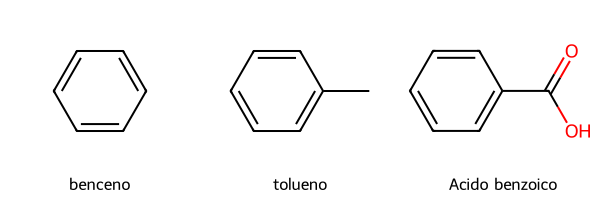

In [85]:
# Ejemplo pequeño de Tanimoto con tres moléculas conocidas.
!pip -q install rdkit
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Draw

ejemplos = {"benceno":"c1ccccc1", "tolueno":"Cc1ccccc1",
            " Acido benzoico":"O=C(O)c1ccccc1"}
mols_ejemplo = {nombre:Chem.MolFromSmiles(smiles) for nombre,smiles in ejemplos.items()}

# radius=2 codifica entornos hasta dos enlaces; fpSize es la longitud del vector.
generador = AllChem.GetMorganGenerator(radius=2, fpSize=2048)
fps = {nombre:generador.GetFingerprint(mol) for nombre,mol in mols_ejemplo.items()}

for nombre_a in ejemplos:
 for nombre_b in ejemplos:
  valor = DataStructs.TanimotoSimilarity(fps[nombre_a], fps[nombre_b])
  print(f"{nombre_a:16s} vs {nombre_b:16s}: {valor:.3f}")

display(Draw.MolsToGridImage(list(mols_ejemplo.values()), legends=list(mols_ejemplo), molsPerRow=3))

## Preparar las consultas FASTA

LigQ2 Web necesita que el usuario seleccione un archivo FASTA desde el navegador. Aunque `P78021.fasta` ya fue descargado dentro del entorno de Colab, la página web no puede leer directamente la carpeta `/content`. Por eso esta celda hace una única descarga al equipo local: luego se selecciona ese archivo en LigQ2. Para el segundo blanco, descarguen su FASTA desde UniProt.

In [ ]:
from google.colab import files

# Descargamos el FASTA de LigA al equipo para seleccionarlo en LigQ2 Web.
files.download(str(DATA_DIR/"P78021.fasta"))
print("Archivo preparado: P78021.fasta")

## Búsqueda web

1. Abran [LigQ2 Web](https://ligq.infra.cluster.qb.fcen.uba.ar).
2. Consulten `P78021.fasta` y el FASTA de su segundo blanco.
3. Usen `Nearest-k`, hasta 5 proteínas, Morgan/ECFP y el cutoff ofrecido.
4. Descarguen el ZIP completo de cada búsqueda.

La instancia pública usa caches precomputadas. No obtener resultados puede reflejar cobertura de datos y no ausencia biológica de ligandos.

## Cargar resultados

Carguen el ZIP obtenido para P78021. Si la web está ocupada, cancelen el selector: se usará la salida de respaldo incluida.

In [16]:
from google.colab import files
import zipfile,shutil
up=files.upload(); zs=[n for n in up if n.lower().endswith(".zip")]
z=Path(zs[0]) if zs else DATA_DIR/"ligq_ligA_results.zip"
LIGQ_DIR=Path("/content/ligq_ligA")
if LIGQ_DIR.exists(): shutil.rmtree(LIGQ_DIR)
LIGQ_DIR.mkdir()
with zipfile.ZipFile(z) as f: f.extractall(LIGQ_DIR)
print("Extraído",z)

Extraído /content/datos_tp/ligq_ligA_results.zip


In [17]:
# El ZIP puede contener carpetas con nombres distintos; rglob localiza cada TSV.
def localizar(nombre):
 archivos = list(LIGQ_DIR.rglob(nombre))
 assert archivos, f"No se encontró {nombre}"
 return archivos[0]

# Leemos por separado cada nivel de la cadena de evidencia.
summary = pd.read_csv(localizar("search_results_summary.tsv"), sep="	")
proteinas = pd.read_csv(localizar("protein_ranking.tsv"), sep="	")
conocidos = pd.read_csv(localizar("known_ligands.tsv"), sep="	")
predichos = pd.read_csv(localizar("predicted_ligands.tsv"), sep="	")

print(f"Proteínas que aportaron ligandos: {len(proteinas)}")
print(f"Ligandos con evidencia previa: {len(conocidos)}")
print(f"Compuestos similares recuperados de ZINC: {len(predichos)}")

Proteínas que aportaron ligandos: 5
Ligandos con evidencia previa: 8
Compuestos similares recuperados de ZINC: 23


### Cómo leer las tablas descargadas

En `protein_ranking.tsv`, `qseqid` identifica nuestra consulta y `sseqid` la proteína encontrada. En `known_ligands.tsv`, `chem_comp_id` es el identificador del compuesto y `pdb_ids` enumera estructuras que lo contienen. Cuando hay datos de ChEMBL, `pchembl` resume potencia en una escala logarítmica: valores mayores suelen indicar mayor potencia, pero sólo deben compararse ensayos compatibles.

En `predicted_ligands.tsv`, `query_id` es el ligando conocido usado como semilla, `chem_comp_id` es el candidato de ZINC y `tanimoto` cuantifica la similitud entre ambos fingerprints.

### Cómo leer la comparación entre proteínas

- `blast_pident`: porcentaje de posiciones idénticas dentro del alineamiento.
- `blast_qcov`: fracción de la proteína consulta cubierta por el alineamiento.
- `blast_scov`: fracción de la proteína encontrada que quedó cubierta.
- `blast_evalue`: cantidad de alineamientos semejantes esperados por azar en una base de ese tamaño. Cuanto menor, más significativa es la coincidencia.
- `n_shared_domains`: número de dominios anotados compartidos.

Una identidad alta sobre un fragmento corto no equivale a identidad moderada sobre toda la proteína. Una cobertura casi completa con ~40 % de identidad apoya una relación homóloga, pero no garantiza conservación exacta del pocket, afinidad ni efecto celular.

In [18]:
# Tabla con las métricas necesarias para auditar cada homólogo.
display(proteinas[["protein_rank","sseqid","blast_pident","blast_qcov",
                   "blast_scov","blast_evalue","n_shared_domains"]])

,protein_rank,sseqid,blast_pident,blast_qcov,blast_scov,blast_evalue,n_shared_domains
0,1,Q837V6,39.517,1.007599,0.980769,6.420000e-164,1
1,2,Q9AIU7,37.879,1.003040,0.989505,4.390000e-149,1
2,3,C1CKI0,39.666,1.000000,1.009202,9.730000e-149,1
3,4,P15042,37.651,1.009119,0.989568,5.720000e-146,1
4,5,P43813,36.199,1.007599,0.989552,2.410000e-137,1


### Resumen gráfico de la búsqueda

Los gráficos siguientes responden tres preguntas diferentes: cuánta evidencia recuperó LigQ2, cuántos ligandos conocidos aporta cada proteína relacionada y qué ligandos semilla originaron la expansión química hacia ZINC.

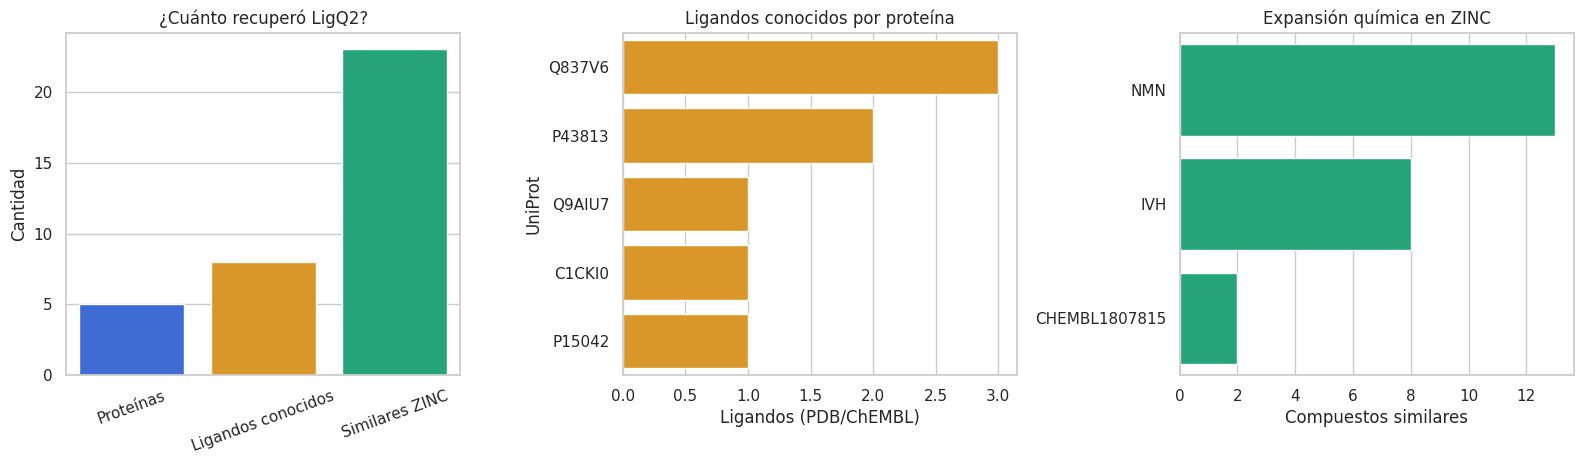

In [19]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.8))

# 1) Tamaño de cada nivel del resultado.
conteos = pd.DataFrame({"resultado":["Proteínas","Ligandos conocidos","Similares ZINC"],
                        "cantidad":[len(proteinas),len(conocidos),len(predichos)]})
sns.barplot(data=conteos, x="resultado", y="cantidad", hue="resultado",
            palette=["#2563EB","#F59E0B","#10B981"], legend=False, ax=ax[0])
ax[0].set(title="¿Cuánto recuperó LigQ2?", xlabel="", ylabel="Cantidad")
ax[0].tick_params(axis="x",rotation=20)

# 2) Número de ligandos conocidos asociado a cada proteína relacionada.
# Reindexamos para que también aparezcan proteínas con cero ligandos.
ids_proteinas = proteinas["sseqid"].astype(str).tolist()
ligandos_por_proteina = conocidos["uniprot_id"].astype(str).value_counts()
conteo_known = pd.DataFrame({"proteina":ids_proteinas})
conteo_known["ligandos_conocidos"] = conteo_known["proteina"].map(ligandos_por_proteina).fillna(0)
conteo_known = conteo_known.sort_values("ligandos_conocidos", ascending=False)
sns.barplot(data=conteo_known, y="proteina", x="ligandos_conocidos",
            color="#F59E0B", ax=ax[1])
ax[1].set(title="Ligandos conocidos por proteína", xlabel="Ligandos (PDB/ChEMBL)", ylabel="UniProt")

# 3) Cantidad de candidatos producidos por cada ligando semilla.
por_semilla = predichos["query_id"].value_counts().rename_axis("ligando semilla").reset_index(name="candidatos")
sns.barplot(data=por_semilla, y="ligando semilla", x="candidatos", color="#10B981", ax=ax[2])
ax[2].set(title="Expansión química en ZINC", xlabel="Compuestos similares", ylabel="")

plt.tight_layout(); plt.show()

## Q837V6 — 4LH6 — inhibidor 1X7

LigQ2 recupera `Q837V6`, LigA de *Enterococcus faecalis*, como primera proteína relacionada (~39.5 % de identidad, cobertura casi completa y dominio de adenilación PF01653 compartido). Esta proteína es útil porque posee evidencia estructural que P78021 no tiene.

[4LH6](https://www.rcsb.org/structure/4LH6) es una estructura cristalográfica de ese dominio, resuelta a 1.65 Å. Contiene dos moléculas especialmente informativas:

- **1X7:** una tienopiridina que inhibe LigA y ocupa la zona que normalmente reconoce la adenosina de NAD⁺;
- **NMN:** el fragmento de nicotinamida de NAD⁺, presente junto al inhibidor.

El objetivo del visualizador es observar evidencia directa de que una molécula pequeña puede ocupar ese sitio en una LigA homóloga. No estamos viendo todavía P78021 ni una predicción de docking.

El artículo también estudia una mutación de resistencia: en *S. pneumoniae*, cambiar Leu75 por Phe reduce la unión de otras familias de inhibidores. 1X7 fue diseñado para no invadir esa región. Este detalle muestra por qué conocer la pose puede ayudar a diseñar alrededor de resistencia, pero no es necesario memorizar la mutación. 1X7 tuvo IC₅₀ de 77 µM frente a LigA de *E. faecalis* y no mostró actividad celular: es un punto de partida estructural, no un antibiótico.

In [78]:
from pathlib import Path
from urllib.request import urlretrieve
import py3Dmol

urlretrieve("https://files.rcsb.org/download/4LH6.pdb", "/content/4LH6.pdb")
pdb4 = Path("/content/4LH6.pdb").read_text()

v = py3Dmol.view(width=950, height=600)
v.addModel(pdb4, "pdb")

# Proteína en cartoon
v.setStyle({}, {"cartoon": {"color": "blue"}})

# Ligandos resaltados
v.setStyle({"resn": "1X7"}, {"stick": {"color": "green", "radius": 0.32}})
v.setStyle({"resn": "NMN"}, {"stick": {"color": "orange", "radius": 0.27}})

# Etiquetas
v.addLabel("1X7", {"fontColor": "green", "fontSize": 14}, {"resn": "1X7"})
v.addLabel("NMN", {"fontColor": "orange", "fontSize": 14}, {"resn": "NMN"})

v.zoomTo()
v.show()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

En esta vista: gris = proteína; verde = 1X7; naranja = NMN; cian = aminoácidos a menos de 4 Å de 1X7; celeste translúcido = superficie local de la cavidad. La superficie no es un segundo pocket de FPocket: es una ayuda visual para ver la cavidad alrededor del ligando cristalográfico.

Giren la estructura y observen que 1X7 está alojado en una cavidad, no simplemente apoyado sobre una superficie plana. Esta pose experimental sirve como referencia para juzgar una pose propuesta en P78021.

### ¿Qué hace el alineamiento estructural?

La celda siguiente superpone 4LH6, una estructura experimental de una LigA homóloga, sobre el modelo AlphaFold de P78021. `cmd.align` busca regiones equivalentes y calcula una rotación y una traslación que minimizan la distancia entre ellas: P78021 queda fijo y se mueve 4LH6.

Después se muestran el Pocket 1 de P78021 y la posición experimental de 1X7. Si ambas regiones coinciden espacialmente, aumenta la plausibilidad de que las proteínas conserven una cavidad equivalente. Esto no demuestra que 1X7 se una a P78021 ni que sea un antibiótico eficaz; es una hipótesis estructural para explorar. Observen qué cambia al activar o desactivar cada casilla.

In [74]:
!pip -q install pymol-open-source

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 32.8 MB/s eta 0:00:00


In [86]:
from pymol import cmd
from pathlib import Path
import py3Dmol
from ipywidgets import interact, Checkbox, FloatSlider, Layout
from IPython.display import display, clear_output

# --- Alineación PyMOL (se ejecuta una vez al principio) ---
cmd.reinitialize()
cmd.load(str(DATA_DIR/"AF_P78021.pdb"), "af_original")
cmd.load("/content/4LH6.pdb", "exp_original")

# Alinear 'exp_original' (4LH6) a 'af_original' (AlphaFold) y guardar el PDB alineado de 4LH6.
cmd.align("exp_original", "af_original")
cmd.save("/content/4LH6_aligned.pdb", "exp_original")

# --- Cargar contenidos PDB/PQR para py3Dmol ---
af_content = Path(str(DATA_DIR/"AF_P78021.pdb")).read_text() # Contenido del modelo AlphaFold original (sin alinear, ya que 'exp' se alinea a 'af')
exp_aligned_content = Path("/content/4LH6_aligned.pdb").read_text() # Contenido del modelo experimental alineado
pqr_content = (DATA_DIR/"AF_P78021_pocket1_vert.pqr").read_text()

# --- Visualización interactiva con py3Dmol ---
def interactive_visualization(
    show_af=True,
    show_exp_aligned=True,
    show_pocket=True,
    show_ligands=True,
    pocket_opacity=0.85
):
    # Limpiar la salida anterior para una experiencia interactiva más limpia
    clear_output(wait=True)
    v = py3Dmol.view(width=950, height=650)

    # Los índices de modelo se asignan incrementalmente por addModel
    current_model_idx = 0
    exp_aligned_model_id = -1 # Para referenciar los ligandos en el modelo experimental

    if show_af:
        v.addModel(af_content, "pdb")
        v.setStyle({"model": current_model_idx}, {"cartoon": {"color": "lightgray"}})
        current_model_idx += 1

    if show_pocket:
        v.addModel(pqr_content, "pqr")
        v.setStyle(
            {"model": current_model_idx},
            {"sphere": {"color": "gold", "radius": 0.7, "opacity": pocket_opacity}}
        )
        current_model_idx += 1

    if show_exp_aligned:
        v.addModel(exp_aligned_content, "pdb")
        v.setStyle({"model": current_model_idx}, {"cartoon": {"color": "blue"}})
        exp_aligned_model_id = current_model_idx # Guardar el ID del modelo experimental para los ligandos
        current_model_idx += 1

        if show_ligands:
            # Los ligandos son parte de la estructura experimental
            if exp_aligned_model_id != -1: # Asegurarse de que el modelo experimental fue añadido
                v.setStyle(
                    {"model": exp_aligned_model_id, "resn": "1X7"},
                    {"stick": {"color": "green", "radius": 0.32}}
                )
                v.setStyle(
                    {"model": exp_aligned_model_id, "resn": "NMN"},
                    {"stick": {"color": "orange", "radius": 0.27}}
                )
                # Etiquetas para los ligandos
                v.addLabel("1X7", {"fontColor": "green", "fontSize": 14}, {"model": exp_aligned_model_id, "resn": "1X7"})
                v.addLabel("NMN", {"fontColor": "orange", "fontSize": 14}, {"model": exp_aligned_model_id, "resn": "NMN"})

    v.zoomTo() # Ajustar el zoom para ver todos los modelos actualmente cargados
    v.show()

# Mostrar los widgets interactivos
interact(
    interactive_visualization,
    show_af=Checkbox(value=True, description="Mostrar AlphaFold (gris)", layout=Layout(width='auto')),
    show_exp_aligned=Checkbox(value=True, description="Mostrar Experimental (azul) (alineado)", layout=Layout(width='auto')),
    show_pocket=Checkbox(value=True, description="Mostrar Pocket (esferas doradas)", layout=Layout(width='auto')),
    show_ligands=Checkbox(value=True, description="Mostrar Ligandos (verde/naranja)", layout=Layout(width='auto')),
    pocket_opacity=FloatSlider(value=0.85, min=0, max=1, step=0.05, description="Opacidad Pocket")
);

interactive(children=(Checkbox(value=True, description='Mostrar AlphaFold (gris)', layout=Layout(width='auto')…

In [21]:
display(conocidos[["uniprot_id","chem_comp_id","source","pdb_ids","pchembl","smiles"]])
sim_1x7=predichos[predichos.query_id.astype(str).str.upper().eq("1X7")]
print("Similares directos de 1X7:",len(sim_1x7)); display(sim_1x7.sort_values("tanimoto",ascending=False).head(20))

,uniprot_id,chem_comp_id,source,pdb_ids,pchembl,smiles
0,Q837V6,1X7,pdb,['4lh6'],NaN,c1c2c(c(cnc2N)C(=O)N)sc1Br
1,Q837V6,1X8,pdb,['4lh7'],NaN,c1c2c(c(cnc2N)C(=O)N)sc1C(=O)N
2,Q837V6,NMN,pdb,['4lh6' '4lh7'],NaN,c1cc(c[n+](c1)[C@H]2[C@@H]([C@@H]([C@H](O2)COP...
3,Q9AIU7,CHEMBL1807815,chembl,[],6.37,Nc1nc(OC2CCCC2)nc2c1ncn2[C@@H]1O[C@H](CO)[C@@H...
4,C1CKI0,0XT,pdb,['4glw'],NaN,Cc1c(nc2c(n1)c(nc(n2)N)N)OC
5,P15042,0XS,pdb,['4glx'],NaN,c1c2cc(c(nc2nc(c1C(=O)N)N)C(F)(F)F)Br
6,P43813,IVH,pdb,['3pn1'],NaN,CCCCSc1nc(c2c(n1)n(cn2)[C@H]3[C@@H]([C@@H]([C@...
7,P43813,IWH,pdb,['3pn1' '4uco' '4ucr' '4ucs' '4uct' '4ucu' '4u...,NaN,Cc1ccc(c(c1)C)CN2C=C(C=CC2=O)C(=O)N


Similares directos de 1X7: 0


,search_type,uniprot_id,chem_comp_id,query_id,tanimoto,smiles,qseqid,sseqid


**Para discutir:** ¿por qué pueden abundar análogos de NMN y faltar análogos de 1X7? ¿Qué papel tienen base, fingerprint y cutoff? ¿Tanimoto alto implica conservar pose y actividad?

# Parte III — Propiedades y ADMET

Un **SMILES** es una forma textual de representar una estructura química. Por ejemplo, `CCO` representa etanol y los números permiten indicar cierres de anillos. LigQ2 entrega SMILES para que los compuestos puedan procesarse sin descargar un archivo estructural para cada uno.

Primero calcularemos propiedades fisicoquímicas con RDKit:

- `MW`: masa molecular;
- `logP`: preferencia estimada por una fase lipídica frente al agua;
- `HBD` y `HBA`: donantes y aceptores de puentes de hidrógeno;
- `TPSA`: superficie polar topológica, relacionada con permeabilidad;
- `QED`: resumen de semejanza con fármacos conocidos, entre 0 y 1;
- `Lipinski_violations`: número de límites de la regla de cinco que no se cumplen.

La regla de Lipinski es una guía para biodisponibilidad oral, no una ley ni una medida de actividad antibacteriana. Moléculas naturales, fragmentos y antibióticos pueden apartarse de ella.

Después, **ADMET-AI** estimará Absorción, Distribución, Metabolismo, Excreción y Toxicidad mediante modelos entrenados con datasets experimentales. Una probabilidad de carcinogenicidad, AMES o hERG no es un diagnóstico toxicológico y puede ser menos confiable fuera del dominio químico de entrenamiento. Estas propiedades sirven para ordenar compuestos, no para decidir si una proteína es un buen blanco.

In [22]:
# Instalamos las bibliotecas químicas en el entorno temporal de Colab.
!pip -q install rdkit admet-ai
from rdkit import Chem
from rdkit.Chem import Descriptors,Lipinski,Crippen,QED

# Conservamos el identificador, el SMILES y la procedencia de cada molécula.
k=conocidos[["chem_comp_id","smiles"]].assign(origen="conocido")
z=predichos[["chem_comp_id","smiles","tanimoto","query_id"]].assign(origen="similar_ZINC")

# Unimos ambas tablas, quitamos SMILES ausentes y evitamos predecir duplicados.
moleculas=pd.concat([k,z],ignore_index=True).dropna(subset=["smiles"]).drop_duplicates("smiles").reset_index(drop=True)
print("SMILES únicos:",len(moleculas))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 959.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.3/14.3 MB 77.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.3/154.3 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 329.9/329.9 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.0/176.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 49.6 MB/s eta 0:00:00
SMILES únicos: 31


In [23]:
def props(smiles):
 # Convertimos el texto SMILES en un objeto molecular de RDKit.
 m=Chem.MolFromSmiles(smiles)
 if m is None:
  return pd.Series(dtype=float)

 # Calculamos descriptores independientes de una conformación 3D.
 mw=Descriptors.MolWt(m)
 lp=Crippen.MolLogP(m)
 hbd=Lipinski.NumHDonors(m)
 hba=Lipinski.NumHAcceptors(m)

 # Cada comparación booleana vale 1 si se viola ese límite de Lipinski.
 return pd.Series({"MW":mw,"logP":lp,"HBD":hbd,"HBA":hba,"TPSA":Descriptors.TPSA(m),"QED":QED.qed(m),
 "Lipinski_violations":sum([mw>500,lp>5,hbd>5,hba>10])})
moleculas=pd.concat([moleculas,moleculas.smiles.apply(props)],axis=1)
display(moleculas.sort_values(["Lipinski_violations","QED"],ascending=[True,False]).head(30))

,chem_comp_id,smiles,origen,tanimoto,query_id,MW,logP,HBD,HBA,TPSA,QED,Lipinski_violations
7,IWH,Cc1ccc(c(c1)C)CN2C=C(C=CC2=O)C(=O)N,conocido,NaN,NaN,256.305,1.61234,1.0,2.0,65.09,0.906336,0.0
5,0XS,c1c2cc(c(nc2nc(c1C(=O)N)N)C(F)(F)F)Br,conocido,NaN,NaN,335.083,2.09220,2.0,4.0,94.89,0.834242,0.0
0,1X7,c1c2c(c(cnc2N)C(=O)N)sc1Br,conocido,NaN,NaN,272.127,1.73990,2.0,4.0,82.00,0.829061,0.0
1,1X8,c1c2c(c(cnc2N)C(=O)N)sc1C(=O)N,conocido,NaN,NaN,236.256,0.07630,3.0,5.0,125.09,0.681963,0.0
4,0XT,Cc1c(nc2c(n1)c(nc(n2)N)N)OC,conocido,NaN,NaN,206.209,-0.09878,2.0,7.0,112.83,0.669305,0.0
3,CHEMBL1807815,Nc1nc(OC2CCCC2)nc2c1ncn2[C@@H]1O[C@H](CO)[C@@H...,conocido,NaN,NaN,351.363,-0.65860,4.0,9.0,148.77,0.562941,0.0
20,ZINC25756940,C[C@@H]1[C@@H](COP(=O)(O)O)O[C@@H]([n+]2cccc(C...,similar_ZINC,0.760000,NMN,331.285,0.35190,3.0,4.0,122.96,0.528415,0.0
21,ZINC13815023,COc1nc(N)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[C@H]...,similar_ZINC,0.722222,CHEMBL1807815,297.271,-1.97140,4.0,9.0,148.77,0.505613,0.0
22,ZINC49053484,COc1nc(N)c2ncn([C@H]3O[C@@H](CO)[C@H](O)[C@@H]...,similar_ZINC,0.722222,CHEMBL1807815,297.271,-1.97140,4.0,9.0,148.77,0.505613,0.0
23,ZINC34495511,CCCSc1nc(N)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[C@...,similar_ZINC,0.884615,IVH,341.393,-0.47790,4.0,9.0,139.54,0.419182,0.0


In [35]:
from admet_ai import ADMETModel

# Cargamos una sola vez el conjunto de modelos preentrenados.
modelo=ADMETModel()

# La predicción por lote es mucho más eficiente que una molécula por vez.
admet=modelo.predict(smiles=moleculas.smiles.tolist()).reset_index(drop=True)

# Eliminamos la columna 'QED' de admet si existe para evitar duplicados,
# ya que ya la calculamos en 'moleculas' con RDKit.
if 'QED' in admet.columns:
    admet = admet.drop(columns=['QED'])

# Unimos las predicciones con identificadores y propiedades de RDKit.
resultados=pd.concat([moleculas,admet.drop(columns=["smiles"],errors="ignore")],axis=1)
print(list(admet.columns))

model ensembles:   0%|          | 0/2 [00:00<?, ?it/s]INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

/usr/local/lib/python3.13/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()

Output()

...

Output()

Output()

Output()

model ensembles: 100%|██████████| 2/2 [00:01<00:00,  1.31it/s]


['molecular_weight', 'logP', 'hydrogen_bond_acceptors', 'hydrogen_bond_donors', 'Lipinski', 'stereo_centers', 'tpsa', 'PAINS_alert', 'BRENK_alert', 'NIH_alert', 'AMES', 'BBB_Martins', 'Bioavailability_Ma', 'CYP1A2_Veith', 'CYP2C19_Veith', 'CYP2C9_Substrate_CarbonMangels', 'CYP2C9_Veith', 'CYP2D6_Substrate_CarbonMangels', 'CYP2D6_Veith', 'CYP3A4_Substrate_CarbonMangels', 'CYP3A4_Veith', 'Carcinogens_Lagunin', 'ClinTox', 'DILI', 'HIA_Hou', 'NR-AR-LBD', 'NR-AR', 'NR-AhR', 'NR-Aromatase', 'NR-ER-LBD', 'NR-ER', 'NR-PPAR-gamma', 'PAMPA_NCATS', 'Pgp_Broccatelli', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53', 'Skin_Reaction', 'hERG', 'Caco2_Wang', 'Clearance_Hepatocyte_AZ', 'Clearance_Microsome_AZ', 'Half_Life_Obach', 'HydrationFreeEnergy_FreeSolv', 'LD50_Zhu', 'Lipophilicity_AstraZeneca', 'PPBR_AZ', 'Solubility_AqSolDB', 'VDss_Lombardo', 'molecular_weight_drugbank_approved_percentile', 'logP_drugbank_approved_percentile', 'hydrogen_bond_acceptors_drugbank_approved_percentile', 'hydrogen

### Interpretar el panel ADMET

- `Solubility_AqSolDB`: solubilidad acuosa predicha, expresada como log mol/L; un valor menos negativo indica mayor solubilidad.
- `HIA_Hou`: probabilidad de absorción intestinal humana.
- `Bioavailability_Ma`: probabilidad asociada con biodisponibilidad oral.
- `AMES`: probabilidad de mutagenicidad en el ensayo de Ames.
- `Carcinogens_Lagunin`: probabilidad predicha de carcinogenicidad según ese dataset.
- `hERG`: probabilidad de bloquear el canal cardíaco hERG, una alerta de cardiotoxicidad.
- `DILI`: probabilidad asociada con daño hepático inducido por fármacos.

Las columnas de clasificación se leen como salidas probabilísticas del modelo, no como porcentajes de toxicidad en pacientes. Cada endpoint fue entrenado con un dataset y una definición diferentes; por eso evitamos sumarlos sin justificación en un único score.

In [36]:
deseadas=["chem_comp_id","origen","MW","logP","TPSA","QED","Lipinski_violations","Solubility_AqSolDB",
 "HIA_Hou","Bioavailability_Ma","AMES","Carcinogens_Lagunin","hERG","DILI"]
display(resultados[[c for c in deseadas if c in resultados]].sort_values(["Lipinski_violations","QED"],ascending=[True,False]).head(30))

,chem_comp_id,origen,MW,logP,logP,TPSA,QED,Lipinski_violations,Solubility_AqSolDB,HIA_Hou,Bioavailability_Ma,AMES,Carcinogens_Lagunin,hERG,DILI
7,IWH,conocido,256.305,1.61234,1.61234,65.09,0.906336,0.0,-2.699594,0.999749,0.885835,0.191869,0.124779,0.409856,0.731378
5,0XS,conocido,335.083,2.09220,2.09220,94.89,0.834242,0.0,-4.304420,0.999362,0.933646,0.493240,0.290566,0.303369,0.957883
0,1X7,conocido,272.127,1.73990,1.73990,82.00,0.829061,0.0,-4.052281,0.999053,0.862524,0.562423,0.251733,0.167625,0.890563
1,1X8,conocido,236.256,0.07630,0.07630,125.09,0.681963,0.0,-3.231006,0.996408,0.903133,0.677579,0.214349,0.060129,0.858451
4,0XT,conocido,206.209,-0.09878,-0.09878,112.83,0.669305,0.0,-2.782553,0.999689,0.961360,0.784107,0.226144,0.152407,0.979231
3,CHEMBL1807815,conocido,351.363,-0.65860,-0.65860,148.77,0.562941,0.0,-2.708081,0.926118,0.789684,0.766312,0.123699,0.514516,0.951661
20,ZINC25756940,similar_ZINC,331.285,0.35190,0.35190,122.96,0.528415,0.0,-0.634439,0.004769,0.060045,0.024241,0.106586,0.056136,0.013203
21,ZINC13815023,similar_ZINC,297.271,-1.97140,-1.97140,148.77,0.505613,0.0,-1.437521,0.876109,0.767709,0.802475,0.129908,0.216486,0.949739
22,ZINC49053484,similar_ZINC,297.271,-1.97140,-1.97140,148.77,0.505613,0.0,-1.436371,0.871776,0.772745,0.812645,0.122369,0.201842,0.950967
23,ZINC34495511,similar_ZINC,341.393,-0.47790,-0.47790,139.54,0.419182,0.0,-2.380143,0.760828,0.708742,0.848510,0.155952,0.254186,0.909647


### Filtro fijo de compuestos

Ahora aplicaremos un filtro común para todos los grupos. Los límites son deliberadamente simples y conservadores:

- como máximo **una violación** de Lipinski: evita descartar automáticamente fragmentos o antibióticos atípicos;
- `QED ≥ 0.30`: retiene moléculas con un mínimo de características de drug-likeness;
- `AMES ≤ 0.50` y `Carcinogens_Lagunin ≤ 0.50`: no prioriza moléculas con una alerta toxicológica predicha alta.

Estos límites no convierten un compuesto en seguro ni activo. La actividad consiste en contar cuántos SMILES pasan, observar cuáles se pierden y discutir si el filtro es apropiado para un antibacteriano.

In [37]:
# Filtro fijo: todos los grupos parten de la misma regla para comparar resultados.
MAX_VIOLACIONES = 1
MIN_QED = 0.30
MAX_AMES = 0.50
MAX_CARCINOGENICIDAD = 0.50

seleccion = resultados[
    (resultados["Lipinski_violations"] <= MAX_VIOLACIONES)
    & (resultados["QED"] >= MIN_QED)
].copy()

antes_alertas = len(seleccion)
if "AMES" in seleccion.columns:
    seleccion = seleccion[seleccion["AMES"] <= MAX_AMES]
if "Carcinogens_Lagunin" in seleccion.columns:
    seleccion = seleccion[seleccion["Carcinogens_Lagunin"] <= MAX_CARCINOGENICIDAD]

print(f"SMILES antes del filtro: {len(resultados)}")
print(f"Después de Lipinski + QED: {antes_alertas}")
print(f"Después de las alertas toxicológicas: {len(seleccion)}")
display(seleccion[[c for c in deseadas+["smiles"] if c in seleccion]].head(30))

SMILES antes del filtro: 31
Después de Lipinski + QED: 22
Después de las alertas toxicológicas: 7


,chem_comp_id,origen,MW,logP,logP,TPSA,QED,Lipinski_violations,Solubility_AqSolDB,HIA_Hou,Bioavailability_Ma,AMES,Carcinogens_Lagunin,hERG,DILI,smiles
5,0XS,conocido,335.083,2.09220,2.09220,94.89,0.834242,0.0,-4.304420,0.999362,0.933646,0.493240,0.290566,0.303369,0.957883,c1c2cc(c(nc2nc(c1C(=O)N)N)C(F)(F)F)Br
7,IWH,conocido,256.305,1.61234,1.61234,65.09,0.906336,0.0,-2.699594,0.999749,0.885835,0.191869,0.124779,0.409856,0.731378,Cc1ccc(c(c1)C)CN2C=C(C=CC2=O)C(=O)N
16,ZINC77311660,similar_ZINC,336.213,-1.59920,-1.59920,157.63,0.315297,0.0,-0.948763,0.000199,0.006102,0.018023,0.040542,0.014749,0.007284,O=C(O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)O)[C@H...
17,ZINC77311659,similar_ZINC,336.213,-1.59920,-1.59920,157.63,0.315297,0.0,-0.952418,0.000149,0.006480,0.017525,0.051250,0.016314,0.007224,O=C(O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)O)[C@H...
18,ZINC4095572,similar_ZINC,336.213,-1.59920,-1.59920,157.63,0.315297,0.0,-0.961457,0.000125,0.007617,0.014133,0.063558,0.016253,0.007585,O=C(O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)O)[C@@...
19,ZINC77311661,similar_ZINC,336.213,-1.59920,-1.59920,157.63,0.315297,0.0,-0.961320,0.000145,0.006717,0.013997,0.049715,0.014243,0.007346,O=C(O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)O)[C@@...
20,ZINC25756940,similar_ZINC,331.285,0.35190,0.35190,122.96,0.528415,0.0,-0.634439,0.004769,0.060045,0.024241,0.106586,0.056136,0.013203,C[C@@H]1[C@@H](COP(=O)(O)O)O[C@@H]([n+]2cccc(C...


**Para discutir:** ¿qué propiedades importan para un antibacteriano sistémico? ¿Conservarían 1X7 para optimización pese a su potencia? ¿Los análogos cargados de NMN atravesarían una membrana? Elijan uno o dos compuestos equilibrando evidencia de unión, diversidad y propiedades.

# Parte IV — Boltz-2 y docking (opcional/orientativa)

Un docking clásico mantiene rígida o parcialmente flexible una estructura receptora y explora muchas orientaciones del ligando dentro de una caja definida. **Boltz-2**, en cambio, es un modelo generativo que recibe las identidades de las moléculas y predice conjuntamente la estructura del complejo. La proteína y el ligando pueden acomodarse durante la predicción.

Boltz-2 produce modelos tridimensionales y métricas de confianza; también puede estimar afinidad. No valida actividad experimental y una pose única no demuestra unión. Conviene comparar varias muestras y controles conocidos.

Esta parte es **opcional y orientativa**. Si hay tiempo y Colab asigna GPU, usen este [Colab comunitario para Boltz-2](https://colab.research.google.com/github/JKourelis/Colab_Boltz-2/blob/main/Boltz_2_csv.ipynb), construido sobre el paquete oficial. Activen `T4 GPU`. La instalación tarda varios minutos y la GPU gratuita no está garantizada. Si no hay GPU, basta con preparar el CSV y discutir la estrategia.

La siguiente celda prepara proteína A y ligando B. Un **pocket restraint** le informa al modelo qué residuos deberían estar próximos al ligando. Es útil para una hipótesis dirigida, pero una corrida guiada no sirve como validación independiente de ese pocket.

In [ ]:
from Bio import SeqIO

# Leemos únicamente la secuencia, sin el encabezado FASTA.
seq=str(next(SeqIO.parse(DATA_DIR/"P78021.fasta","fasta")).seq)

# Elegimos provisoriamente la primera molécula que pasó los filtros.
# Para probar otra, reemplacen esta selección por su fila de interés.
elegido=seleccion.iloc[0] if len(seleccion) else resultados.iloc[0]

# Una fila del CSV representa un complejo. A es proteína y B es ligando.
boltz=pd.DataFrame([{"jobname":f"LigA_{elegido.chem_comp_id}","seq1_name":"A","seq1_type":"protein","seq1":seq,"seq1_copies":1,
 "seq2_name":"B","seq2_type":"ligand","seq2":elegido.smiles,"seq2_copies":1,"pocket_binder":"B",
 "pocket_contacts":"A:80;A:81;A:110;A:112;A:133;A:167;A:279;A:303"}])

# Guardamos el archivo para cargarlo en el notebook específico de Boltz-2.
boltz.to_csv("/content/boltz_ligA.csv",index=False)
display(boltz)
files.download("/content/boltz_ligA.csv")

## Evaluar el complejo

- ¿El ligando cae en Pocket 1 y cerca de Lys112?
- ¿Contacta features de NAD⁺?
- ¿La confianza local es adecuada y las muestras convergen?
- ¿1X7 reproduce la región cristalográfica de 4LH6?
- ¿La ubicación fue impuesta por restraints?

## ¿Harían docking y dónde ubicarían la grilla?

Sí, como complemento para una biblioteca de análogos sobre receptor fijo. La **grilla** es el volumen del espacio donde el algoritmo buscará poses; si se coloca lejos del sitio relevante, una molécula no podrá encontrarlo aunque sea un ligando verdadero.

Para LigA, centren la grilla en el **sitio adenosina/NAD⁺**, usando el centroide de 1X7 tras superponer 4LH6, las features de NAD⁺ o las esferas de FPocket. Verifiquen que incluya Lys112 y la cavidad hidrofóbica adyacente. La caja debe ser suficientemente grande para alojar sustituyentes, pero no tanto como para explorar innecesariamente toda la proteína.

Incluyan controles, varias poses y estados de protonación/cargas adecuados. El score de docking sirve para priorizar poses bajo las aproximaciones del programa; no equivale a afinidad experimental.